In [9]:
# Install requirements
%pip install huggingface_hub kagglehub datasets

  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 5.8 MB/s  0:00:00
Using cached aiosignal-1.4.0-py3-none-any.whl (7.5 kB)
Using cached attrs-26.1.0-py3-none-any.whl (67 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 54.9 MB/s  0:00:00m0:00:0100:01
  Attempting uninstall: fsspec━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/14 [pyarrow]
    Found existing installation: fsspec 2026.7.0━━━━━━━━━━━━━━  1/14 [pyarrow]
    Uninstalling fsspec-2026.7.0:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/14 [pyarrow]
      Successfully uninstalled fsspec-2026.7.0━━━━━━━━━━━━━━━━  1/14 [pyarrow]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [datasets]/14 [datasets]ess]
Note: you may need to restart the kernel to use updated packages.


In [7]:
import warnings

from huggingface_hub.cli import datasets
from kagglehub import load_dataset
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [10]:
from huggingface_hub import login
from datasets import load_dataset
#login()
dataset = load_dataset("zlab-princeton/Vero-600k", "captioning_IF-flickr30k", split='train', streaming=True)

def transform_to_sepia(example):
    # Get the decoded image with sepia filter applied
    img = example['image'].convert("RGB")
    # Rescale to 32x32: retain the distribution of sepia tones with less data
    img_low = img.resize((32, 32))
    # Apply sepia filter
    sepia_img = img_low.convert("RGB", sepia_matrix)

    return {"sepia_image": sepia_img, "image": img_low}

processed_ds = iter(dataset.map(transform_to_sepia))

In [11]:
from PIL import Image
from pathlib import Path

paths = ["bike1.jpg", "bike02.jpg", "bike03.jpg", "bike04.jpg", "bike05.jpg", "bike06.jpg", "bike07.jpg", "bike08.jpg", "bike09.jpg", "bike10.jpg",
         "traffic01.jpg", "traffic02.jpg", "traffic03.jpg", "traffic04.jpg", "traffic05.jpg", "traffic06.jpg", "traffic07.jpg", "traffic08.jpg", "traffic09.jpg", "traffic10.jpg",]
IMAGES_DIR = Path("./images")
SEPIA_IMAGES_DIR = Path("./sepia-images")



# Common sepia matrix transform
sepia_matrix = (
    0.393, 0.769, 0.189, 0,
    0.349, 0.686, 0.168, 0,
    0.272, 0.534, 0.131, 0
)

# Generate database of sepia images
def sepia_generate(limit = 5000):
    #for path in paths:
    #    img = Image.open(Path("../L04/images/" + path)).convert("RGB")
    #    sepia_img = img.convert("RGB", sepia_matrix)
    #    sepia_img.save(Path("../L07/sepia-images/" + path))

    for _ in range(limit):
        example = next(processed_ds)
        sepia_img = example['sepia_image']
        sepia_img.save(SEPIA_IMAGES_DIR / f"sepia-{len(list(SEPIA_IMAGES_DIR.glob('*')))}.jpg")
        img = example['image']
        img.save(IMAGES_DIR / f"normal-{len(list(IMAGES_DIR.glob('*')))}.jpg")

#sepia_generate()

In [12]:
import numpy as np
from sklearn.utils import shuffle
from PIL import Image

data = []
for i in range(5000):
    data.append(np.array(Image.open(f'./images/normal-{i}.jpg')).flatten()) # convert to 1D array
for i in range(5000):
    data.append(np.array(Image.open(f'./sepia-images/sepia-{i}.jpg')).flatten())

# Set ground truths
expected = [0 for i in range(5000)]
expected.extend([1 for i in range(5000)])
data, expected = shuffle(data, expected, random_state=1)

FileNotFoundError: [Errno 2] No such file or directory: './images/normal-0.jpg'

In [ ]:
import numpy as np

# Split to 80% train, 20% test
def splitData(inputs, outputs):
    np.random.seed(1)
    indexes = [i for i in range(len(inputs))]
    trainIndexes = np.random.choice(indexes, int(0.8 * len(indexes)), replace=False).tolist()
    testIndexes = [i for i in indexes if i not in trainIndexes]

    trainInputs = [inputs[i] for i in trainIndexes]
    testInputs = [inputs[i] for i in testIndexes]
    trainOutputs = [outputs[i] for i in trainIndexes]
    testOutputs = [outputs[i] for i in testIndexes]

    return trainInputs, trainOutputs, testInputs, testOutputs

In [ ]:
# min-max normalization great for pixels
def normalisation(trainData, testData):
    trainData = np.array(trainData, dtype=np.float32) / 255.0 - 0.5
    testData = np.array(testData, dtype=np.float32) / 255.0 - 0.5
    return trainData, testData

In [ ]:
trainInputs, trainOutputs, testInputs, testOutputs = splitData(data, expected)
trainInputs, testInputs = normalisation(trainInputs, testInputs)

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import ParameterGrid

def evaluate_mlp_hyperparameters(X_train, y_train, X_test, y_test):
    # Define the hyperparameter search space
    parameter_grid = {
        'hidden_layer_sizes': [(5,), (10,), (10, 5)],
        'max_iter': [10, 100, 750],
        'learning_rate_init': [0.01, 0.001]
    }

    best_accuracy = 0
    best_params = None
    results = []

    print(f"{'Accuracy':<10} | {'Hyperparameters':^60}")
    print("-" * 90)

    # Grid search through parameters
    for params in ParameterGrid(parameter_grid):
        # Initialize classifier with current parameters
        classifier = MLPClassifier(**params, activation='relu', solver='sgd', random_state=1)

        # Train and evaluate
        classifier.fit(X_train, y_train)
        computed = classifier.predict(X_test)
        acc = accuracy_score(y_test, computed)

        results.append((acc, params))
        print(f"{acc:<10.4f} | {params}")

        # Track the best configuration
        if acc > best_accuracy:
            best_accuracy = acc
            best_params = params

    print("-" * 90)
    print(f"Best Accuracy: {best_accuracy:.4f}")
    print(f"Best Config:   {best_params}")

    #return results, best_params

evaluate_mlp_hyperparameters(trainInputs, trainOutputs, testInputs, testOutputs)

Accuracy   |                       Hyperparameters                       
------------------------------------------------------------------------------------------
0.8450     | {'hidden_layer_sizes': (5,), 'learning_rate_init': 0.01, 'max_iter': 10}
0.8085     | {'hidden_layer_sizes': (5,), 'learning_rate_init': 0.01, 'max_iter': 100}
0.8085     | {'hidden_layer_sizes': (5,), 'learning_rate_init': 0.01, 'max_iter': 750}
0.8095     | {'hidden_layer_sizes': (5,), 'learning_rate_init': 0.001, 'max_iter': 10}
0.8875     | {'hidden_layer_sizes': (5,), 'learning_rate_init': 0.001, 'max_iter': 100}
0.9510     | {'hidden_layer_sizes': (5,), 'learning_rate_init': 0.001, 'max_iter': 750}
0.8735     | {'hidden_layer_sizes': (10,), 'learning_rate_init': 0.01, 'max_iter': 10}
0.9280     | {'hidden_layer_sizes': (10,), 'learning_rate_init': 0.01, 'max_iter': 100}
0.9260     | {'hidden_layer_sizes': (10,), 'learning_rate_init': 0.01, 'max_iter': 750}
0.8065     | {'hidden_layer_sizes': (10,), 'learn

In [ ]:
from sklearn import neural_network
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.utils.extmath")

classifier = neural_network.MLPClassifier(hidden_layer_sizes=(100,), activation='relu', max_iter=750, solver='sgd', verbose=True, learning_rate_init=.001, random_state=1)
classifier.fit(trainInputs, trainOutputs)



Iteration 1, loss = 0.66821363
Iteration 2, loss = 0.60908870
Iteration 3, loss = 0.56998864
Iteration 4, loss = 0.54340216
Iteration 5, loss = 0.52405393
Iteration 6, loss = 0.50831700
Iteration 7, loss = 0.49601361
Iteration 8, loss = 0.48640003
Iteration 9, loss = 0.47664213
Iteration 10, loss = 0.46879316
Iteration 11, loss = 0.46140869
Iteration 12, loss = 0.45400668
Iteration 13, loss = 0.44650842
Iteration 14, loss = 0.44046379
Iteration 15, loss = 0.43336650
Iteration 16, loss = 0.42715016
Iteration 17, loss = 0.42051480
Iteration 18, loss = 0.41448788
Iteration 19, loss = 0.40744718
Iteration 20, loss = 0.40191576
Iteration 21, loss = 0.39546889
Iteration 22, loss = 0.38909772
Iteration 23, loss = 0.38335851
Iteration 24, loss = 0.37685895
Iteration 25, loss = 0.37035904
Iteration 26, loss = 0.36475523
Iteration 27, loss = 0.35899012
Iteration 28, loss = 0.35289566
Iteration 29, loss = 0.34738855
Iteration 30, loss = 0.34162848
Iteration 31, loss = 0.33653132
Iteration 32, los

MLPClassifier(max_iter=750, random_state=1, solver='sgd', verbose=True)

In [ ]:
def plotConfusionMatrix(y_true, y_pred, display_labels=['Normal', 'Sepia']):
    cm = confusion_matrix(y_true, y_pred)

    # Initialize and plot the visualization
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap=plt.cm.Blues)

    plt.title("Confusion Matrix")
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predicted = classifier.predict(testInputs)
# Execution
plotConfusionMatrix(testOutputs, predicted)

NameError: name 'classifier' is not defined

In [ ]:
import numpy as np

class CustomANN:
    def __init__(self, input_size, hidden_size=100, output_size=1, learning_rate=0.01, verbose=False):
        self.lr = learning_rate
        self.verbose = verbose

        # He Initialization for ReLU single hidden layer
        self.W_hidden = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)
        self.b_hidden = np.zeros((1, hidden_size))

        # Xavier Initialization for Sigmoid output layer
        self.W_output = np.random.randn(hidden_size, output_size) * np.sqrt(1. / hidden_size)
        self.b_output = np.zeros((1, output_size))

        self.Z_hidden = None
        self.A_hidden = None
        self.Z_output = None
        self.A_output = None

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    @staticmethod
    def sigmoid(z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    # X - np array (n_samples, input_size: 32x32x3)
    def forward(self, X):
        # hidden layer
        self.Z_hidden = np.dot(X, self.W_hidden) + self.b_hidden
        self.A_hidden = self.relu(self.Z_hidden)
        # output layer
        self.Z_output = np.dot(self.A_hidden, self.W_output) + self.b_output
        self.A_output = self.sigmoid(self.Z_output)
        return self.A_output

    # X = np array (n_samples, input_size: 32x32x3)
    # Y = np array (n_samples, output_size: 1)
    def backward(self, X, Y):
        Y = Y.reshape(-1, 1)
        # Output layer gradients
        dZ_output = self.A_output - Y
        dW_output = (1 / len(X)) * np.dot(self.A_hidden.T, dZ_output)
        db_output = (1 / len(X)) * np.sum(dZ_output, axis=0, keepdims=True)

        # Hidden layer gradients
        dA_hidden = np.dot(dZ_output, self.W_output.T)
        self.dZ_hidden = dA_hidden * self.relu_derivative(self.Z_hidden)
        dW_hidden = (1 / len(X)) * np.dot(X.T, self.dZ_hidden)
        db_hidden = (1 / len(X)) * np.sum(self.dZ_hidden, axis=0, keepdims=True)

        dW_output = np.clip(dW_output, -1.0, 1.0)
        db_output = np.clip(db_output, -1.0, 1.0)
        dW_hidden = np.clip(dW_hidden, -1.0, 1.0)
        db_hidden = np.clip(db_hidden, -1.0, 1.0)

        # Update weights
        self.W_hidden -= self.lr * dW_hidden
        self.b_hidden -= self.lr * db_hidden
        self.W_output -= self.lr * dW_output
        self.b_output -= self.lr * db_output

    def fit(self, X, Y, epochs=100):
        for i in range(epochs):
            self.forward(X)
            self.backward(X, Y)

    def fit_batch(self, X, Y, batch_size=32, epochs=100):
        for epoch in range(epochs):
            # Shuffle at the start of each epoch
            indices = np.random.permutation(len(X))
            X_shuffled = X[indices]
            Y_shuffled = Y[indices]

            for i in range(0, len(X), batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                Y_batch = Y_shuffled[i:i+batch_size]

                self.forward(X_batch)
                self.backward(X_batch, Y_batch)

            # Print loss every 10 epochs
            if self.verbose and epoch % 10 == 0:
                computed = self.forward(X)
                # Binary Cross-Entropy Loss
                loss = -np.mean(Y * np.log(computed + 1e-8) + (1 - Y) * np.log(1 - computed + 1e-8))
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    def predict(self, X):
        A_output = self.forward(X)
        return (A_output > 0.5).astype(int).flatten()

In [ ]:
import numpy as np

X_train = np.array(trainInputs)
y_train = np.array(trainOutputs).reshape(-1, 1)

input_dimensions = X_train.shape[1]
ann = CustomANN(input_size=input_dimensions, hidden_size=5, learning_rate=0.01, verbose=True)


ann.fit_batch(X_train, y_train, epochs=750)

Epoch 0, Loss: 0.5519
Epoch 10, Loss: 0.2730
Epoch 20, Loss: 0.2102
Epoch 30, Loss: 0.1655
Epoch 40, Loss: 0.1561
Epoch 50, Loss: 0.1048
Epoch 60, Loss: 0.0915
Epoch 70, Loss: 0.0794
Epoch 80, Loss: 0.0719
Epoch 90, Loss: 0.0786
Epoch 100, Loss: 0.2367
Epoch 110, Loss: 0.0557
Epoch 120, Loss: 0.0495
Epoch 130, Loss: 0.0446
Epoch 140, Loss: 0.0420
Epoch 150, Loss: 0.0381
Epoch 160, Loss: 0.0343
Epoch 170, Loss: 0.0340
Epoch 180, Loss: 0.0315
Epoch 190, Loss: 0.0308
Epoch 200, Loss: 0.0259
Epoch 210, Loss: 0.0276
Epoch 220, Loss: 0.0355
Epoch 230, Loss: 0.0256
Epoch 240, Loss: 0.0286
Epoch 250, Loss: 0.0212
Epoch 260, Loss: 0.0193
Epoch 270, Loss: 0.1995
Epoch 280, Loss: 0.0167
Epoch 290, Loss: 0.0233
Epoch 300, Loss: 0.0163
Epoch 310, Loss: 0.0178
Epoch 320, Loss: 0.0486
Epoch 330, Loss: 0.0135
Epoch 340, Loss: 0.0222
Epoch 350, Loss: 0.0129
Epoch 360, Loss: 0.0180
Epoch 370, Loss: 0.0116
Epoch 380, Loss: 0.0137
Epoch 390, Loss: 0.0113
Epoch 400, Loss: 0.0119
Epoch 410, Loss: 0.0091
Epo

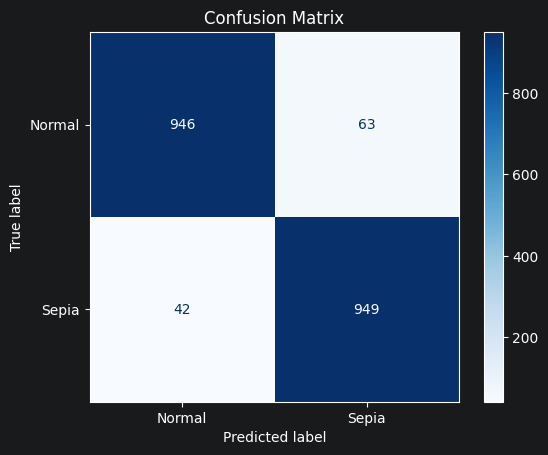

In [ ]:
predicted = ann.predict(testInputs)
plotConfusionMatrix(testOutputs, predicted)

In [ ]:
import numpy as np

class Conv:
    def __init__(self, num_filters, filter_size=3, input_channels=3):
        self.num_filters = num_filters
        self.f = filter_size
        self.c = input_channels
        self.last_input = None

        # He initialization scaled for the 3D volume
        fan_in = self.f * self.f * self.c
        self.filters = np.random.randn(num_filters, self.f, self.f, self.c) * np.sqrt(2. / fan_in)

    def get_gradients(self, d_out):
        """Calculates gradients for a single image without updating weights."""
        d_filters = np.zeros(self.filters.shape)
        for im_region, i, j in self.iterate_regions(self.last_input):
            for f in range(self.num_filters):
                d_filters[f] += d_out[i, j, f] * im_region
        return d_filters

    def update_filters(self, d_filters_avg, lr):
        """Applies the averaged batch gradient."""
        self.filters -= lr * d_filters_avg

    def iterate_regions(self, image):
        # image is now (h, w, c)
        h, w, c = image.shape
        for i in range(h - self.f + 1):
            for j in range(w - self.f + 1):
                # Extract the 3D block
                im_region = image[i:(i + self.f), j:(j + self.f), :]
                yield im_region, i, j

    def forward(self, input_image):
        self.last_input = input_image
        h, w, c = input_image.shape
        output = np.zeros((h - self.f + 1, w - self.f + 1, self.num_filters))

        for im_region, i, j in self.iterate_regions(input_image):
            # im_region: (f, f, c)
            # self.filters: (num_filters, f, f, c)
            # np.sum over axes 1 (height), 2 (width), 3 (channels)
            output[i, j] = np.sum(im_region * self.filters, axis=(1, 2, 3))

        return output

    def backward(self, d_out, lr):
        d_filters = np.zeros(self.filters.shape)

        for im_region, i, j in self.iterate_regions(self.last_input):
            for f in range(self.num_filters):
                # d_out[i,j,f] is a scalar, im_region is (f, f, c)
                d_filters[f] += d_out[i, j, f] * im_region

        self.filters -= lr * d_filters

class MaxPool:
    def iterate_regions(self, image):
        h, w, num_filters = image.shape
        new_h = h // 2
        new_w = w // 2

        for i in range(new_h):
            for j in range(new_w):
                im_region = image[(i * 2):(i * 2 + 2), (j * 2):(j * 2 + 2)]
                yield im_region, i, j

    def forward(self, input_volume):
        self.last_input = input_volume
        h, w, num_filters = input_volume.shape
        output = np.zeros((h // 2, w // 2, num_filters))

        for im_region, i, j in self.iterate_regions(input_volume):
            output[i, j] = np.amax(im_region, axis=(0, 1))
        return output

    def backward(self, d_out):
        d_input = np.zeros(self.last_input.shape)

        for im_region, i, j in self.iterate_regions(self.last_input):
            h, w, f = im_region.shape
            amax = np.amax(im_region, axis=(0, 1))

            for i2 in range(h):
                for j2 in range(w):
                    for f2 in range(f):
                        # Propagate gradient only to the pixel that was the maximum
                        if im_region[i2, j2, f2] == amax[f2]:
                            d_input[i * 2 + i2, j * 2 + j2, f2] = d_out[i, j, f2]
        return d_input

In [ ]:
import numpy as np

class CustomCNN:
    def __init__(self, input_dim, num_filters=8, filter_size=3, hidden_size=10, learning_rate=0.01, verbose=False):
        self.input_dim = input_dim
        self.lr = learning_rate
        self.verbose = verbose

        # Extract channels from input_dim
        h, w, c = input_dim

        # Pass 'c' to Conv2D
        self.conv = Conv(num_filters, filter_size, input_channels=c)
        self.pool = MaxPool()

        # Output math remains identical because pooling only touches spatial dims
        conv_out_dim = (h - filter_size + 1)
        pool_out_dim = conv_out_dim // 2
        flat_dim = (pool_out_dim ** 2) * num_filters

        self.ann = CustomANN(
            input_size=flat_dim,
            hidden_size=hidden_size,
            output_size=1,
            learning_rate=learning_rate,
            verbose=verbose
        )

    def forward(self, X_batch):
        # Caches for the backward pass
        self.batch_c_outs = []
        self.batch_a_outs = []
        conv_results = []

        for i in range(X_batch.shape[0]):
            c_out = self.conv.forward(X_batch[i])
            a_out = np.maximum(0, c_out) # ReLU
            p_out = self.pool.forward(a_out)

            # Store states to avoid recalculating during backprop
            self.batch_c_outs.append(c_out)
            self.batch_a_outs.append(a_out)
            conv_results.append(p_out)

        self.last_conv_output = np.array(conv_results)

        # Flatten and pass to Dense Network
        flattened = self.last_conv_output.reshape(X_batch.shape[0], -1)
        return self.ann.forward(flattened)

    def backward(self, X_batch, Y_batch):
        # 1. Dense Backward
        flattened = self.last_conv_output.reshape(X_batch.shape[0], -1)
        self.ann.backward(flattened, Y_batch)

        # 2. Reshape Error Signal
        d_flat = np.dot(self.ann.dZ_hidden, self.ann.W_hidden.T)
        d_pool_out = d_flat.reshape(self.last_conv_output.shape)
        d_filters_total = np.zeros(self.conv.filters.shape)
        # 3. Convolutional Backward
        for i in range(X_batch.shape[0]):
            # Restore forward states for this specific image
            self.conv.last_input = X_batch[i]
            self.pool.last_input = self.batch_a_outs[i]

            # Pool -> ReLU -> Conv derivatives
            d_relu = self.pool.backward(d_pool_out[i])
            d_conv = d_relu * (self.batch_c_outs[i] > 0).astype(float)
            #self.conv.backward(d_conv, self.lr)
            d_filters_total += self.conv.get_gradients(d_conv)

        # 4. Average and Apply ONE update for the batch
        d_filters_avg = d_filters_total / X_batch.shape[0]

        # Gradient Clipping to mathematically prevent NaN explosions
        d_filters_avg = np.clip(d_filters_avg, -1.0, 1.0)

        self.conv.update_filters(d_filters_avg, self.lr)

    def fit_batch(self, X, Y, batch_size=32, epochs=10):
        n_samples = X.shape[0]

        for epoch in range(epochs):
            # Shuffle data
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            Y_shuffled = Y[indices]
            Y_batch = np.array([])

            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                Y_batch = Y_shuffled[i:i+batch_size]

                self.forward(X_batch)
                self.backward(X_batch, Y_batch)

            # Compute loss on the last batch for speed tracking
            if self.verbose:
                computed = self.ann.A_output
                Y_batch = Y_batch.reshape(-1, 1)
                loss = -np.mean(Y_batch * np.log(computed + 1e-8) + (1 - Y_batch) * np.log(1 - computed + 1e-8))
                print(f"Epoch {epoch}, Last Batch Loss: {loss:.4f}")

    def predict(self, X):
        predictions = []
        # Predict in chunks to prevent memory overload on 10k images
        batch_size = 128
        for i in range(0, X.shape[0], batch_size):
            X_batch = X[i:i+batch_size]
            batch_preds = self.forward(X_batch)
            predictions.append((batch_preds > 0.5).astype(int).flatten())

        return np.concatenate(predictions)

In [ ]:
data = []
for i in range(5000):
    data.append(np.array(Image.open(f'./images/normal-{i}.jpg'))) # convert to 1D array
for i in range(5000):
    data.append(np.array(Image.open(f'./sepia-images/sepia-{i}.jpg')))

# Set ground truths
expected = [0 for i in range(5000)]
expected.extend([1 for i in range(5000)])
data, expected = shuffle(data, expected, random_state=1)
trainInputs, trainOutputs, testInputs, testOutputs = splitData(data, expected)
trainInputs, testInputs = normalisation(trainInputs, testInputs)

In [ ]:
X_train = np.array(trainInputs[:100])
y_train = np.array(trainOutputs[:100]).reshape(-1, 1)
input_dimensions = X_train.shape[1:]
cnn = CustomCNN(input_dimensions, hidden_size=10, learning_rate=0.1, verbose=True)

cnn.fit_batch(X_train, y_train, epochs=20)

Epoch 0, Last Batch Loss: 0.6751
Epoch 1, Last Batch Loss: 0.4753
Epoch 2, Last Batch Loss: 0.5759
Epoch 3, Last Batch Loss: 0.2522
Epoch 4, Last Batch Loss: 0.5018
Epoch 5, Last Batch Loss: 0.4433
Epoch 6, Last Batch Loss: 0.6286
Epoch 7, Last Batch Loss: 1.1581
Epoch 8, Last Batch Loss: 0.4650
Epoch 9, Last Batch Loss: 0.5743
Epoch 10, Last Batch Loss: 0.2615
Epoch 11, Last Batch Loss: 0.2554
Epoch 12, Last Batch Loss: 0.3062
Epoch 13, Last Batch Loss: 0.4612
Epoch 14, Last Batch Loss: 0.4121
Epoch 15, Last Batch Loss: 0.8810
Epoch 16, Last Batch Loss: 0.2431
Epoch 17, Last Batch Loss: 0.5529
Epoch 18, Last Batch Loss: 0.1484
Epoch 19, Last Batch Loss: 0.2327


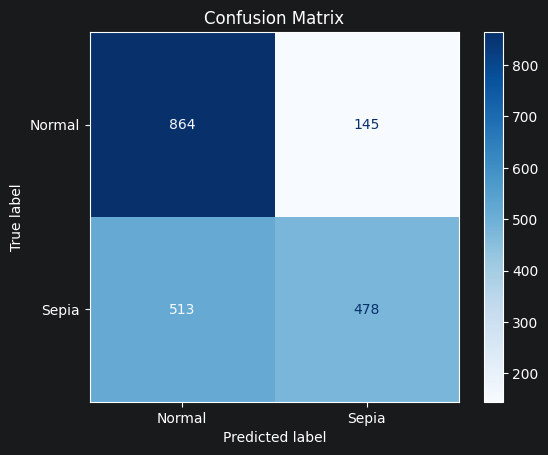

In [ ]:
predicted = cnn.predict(testInputs)
plotConfusionMatrix(testOutputs, predicted)